# 20_异常值处理方法-聚类法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本节咱们来聊聊异常值处理方法方面的聚类法\~

### 什么是异常值？

异常值就是那些“很不正常”的数据，在整体数据中显得“特别离群”。比如大部分人身高在150cm～190cm之间，有个人数据是280cm，那它就可能是异常值。

### 什么是异常值处理？

异常值会影响分析结果（比如平均值被拉高），所以我们要发现这些值，并决定是要剔除、修正、还是单独处理它们。

### 什么是聚类法？

聚类就是“把相似的数据分成一堆堆”，每堆里都是长得差不多的数据，不同堆之间差别比较大。

举个简单的例子，假设我们把学生按学习成绩分组：

- 90分以上一组（学霸）
- 70～89分一组（中等）
- 70分以下一组（待提高）

如果有个人考了 **-10分** 或者 **500分**，显然分不到任何“正常组”里，那这就是异常值了！

再比如：

我们有这样一组数据（表示某天店里顾客的消费金额，单位：元）：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
[50, 55, 60, 53, 58, 52, 510, 54, 59]
```

- 绝大多数在 50～60 之间。
- 其中 **510** 明显特别高，看起来像录入错误或特殊事件，这就可能是异常值。

我们把这些数据聚成几类（比如2类）：

- 一组：50～60
- 一组：510

第二组里就只有一个数，离别的太远——这是一个明显的异常点。

## 数学原理

### Step 1：设定目标

将数据集划分为 $K$ 个聚类，每个聚类内部的数据彼此“相似”，聚类之间的数据“差异大”。

**数学目标函数（K-means）**：


$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$


- $K$：聚类的个数（手动设定，比如2～5）
- $C_k$：第 $k$ 个簇（cluster）
- $\mu_k$：第 $k$ 个簇的中心（均值）
- $x_i$：属于该簇的样本点
- $\|x_i - \mu_k\|^2$：点到中心的欧几里得距离平方

我们希望这个距离和 $J$ 尽量小，每个点尽量离自己那组的“中心”近。

### 异常值的数学定义（在聚类中）

一个数据点 $x_i$ 如果满足：


$$
\|x_i - \mu_k\| \gg \text{其他点到 }\mu_k\text{ 的平均距离}
$$


那么它就可以被认为是“离群点”或“异常值”。

## 算法流程

#### 步骤 1：准备数据

- 拿到数据集，可能要先做归一化（让特征尺度相似）。

#### 步骤 2：选择聚类数 $K$

- 通常取 2～5 个聚类数。
- 可以用“肘部法”来选择最合适的 $K$。

#### 步骤 3：执行聚类（比如 K-means）

- 初始化 $K$ 个中心点（可以随机选）
- 对每个点，计算它离哪一个中心点最近 → 分到那一组
- 对每一组，重新计算该组的中心点（取平均）
- 重复以上过程，直到中心点不再变化或变化很小

#### 步骤 4：识别异常值

- 每个点到它自己组的中心点的距离都可以计算：$d_i = \|x_i - \mu_k\|$
- 统计所有距离的平均值 $\bar{d}$ 和标准差 $\sigma_d$
- 设置阈值，比如：


$$
\text{如果 } d_i > \bar{d} + 2\sigma_d \Rightarrow x_i \text{ 是异常值}
$$


#### 步骤 5：处理异常值

- 删除？修正？单独记录？视情况而定

聚类法是一种**无监督学习方法**，不依赖标签，可以用于很多未知场景。

K-means 对“簇的形状”要求比较严格（适合球状分布），如果数据复杂，可用 DBSCAN、GMM等其他聚类算法。

## 完整案例

大家知道，在现代金融服务中，银行经常需要监控客户的信用卡使用行为，以及时发现**异常消费行为**，例如异常高额交易、频繁小额刷卡等。这不仅关系到风险控制，也能帮助识别欺诈或误操作行为。

假设我们是一家商业银行的数据科学团队，需要通过分析客户月交易记录，发现可能存在的“异常行为客户”。

我们采集了以下特征数据（模拟生成）：

- 每月交易总额（Monthly Amount）
- 每月交易次数（Monthly Count）

使用 **KMeans 聚类算法** 来将客户行为划分为若干组，从而找出那些“非常偏离常规”的客户行为数据点，视作异常值。

### 代码实现

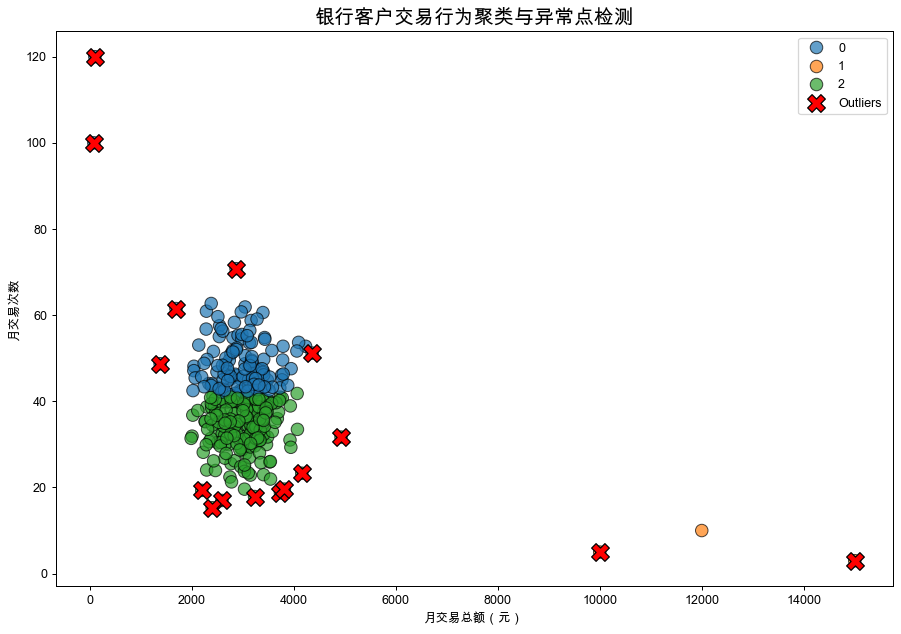

检测到的异常点：
     monthly_amount  monthly_count  distance_to_center
74      1690.127448      61.531825            1.517879
82      3738.947022      18.761043            1.417963
142     2196.258383      19.325579            1.421301
171     2592.094858      16.980788            1.459996
178     2867.671583      70.788808            1.808023
179     4360.084583      51.195749            1.324020
209     4926.365745      31.690499            1.758420
220     4157.329283      23.305947            1.356218
244     2399.851796      15.283555            1.653170
262     1379.366330      48.711247            1.421117
266     3816.205652      19.618755            1.389236
275     3231.051737      17.888647            1.343139
300    10000.000000       5.000000            2.143940
302    15000.000000       3.000000            2.461826
303       80.000000     100.000000            5.049461
304      100.000000     120.000000            6.576388


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# 1 模拟生成客户数据
np.random.seed(42)
normal_customers = pd.DataFrame({
    'monthly_amount': np.random.normal(loc=3000, scale=500, size=300),
    'monthly_count': np.random.normal(loc=40, scale=10, size=300)
})

# 添加一些异常客户
anomalies = pd.DataFrame({
    'monthly_amount': [10000, 12000, 15000, 80, 100],
    'monthly_count': [5, 10, 3, 100, 120]
})

# 合并数据
data = pd.concat([normal_customers, anomalies], ignore_index=True)

# 数据标准化
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# 2 使用KMeans聚类
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
data['cluster'] = kmeans.fit_predict(scaled_data)

# 计算每个点到其聚类中心的距离
centroids = kmeans.cluster_centers_
distances = []
for i, row in enumerate(scaled_data):
    center = centroids[data.loc[i, 'cluster']]
    dist = np.linalg.norm(row - center)
    distances.append(dist)
data['distance_to_center'] = distances

# 3 设置异常值阈值
threshold = np.percentile(data['distance_to_center'], 95)  # 95%以上认为是异常
data['is_outlier'] = data['distance_to_center'] > threshold

# 4 可视化聚类结果
palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=data,
    x='monthly_amount',
    y='monthly_count',
    hue='cluster',
    palette=palette,
    s=100,
    alpha=0.7,
    edgecolor='black'
)
# 标注异常点
outliers = data[data['is_outlier']]
plt.scatter(outliers['monthly_amount'], outliers['monthly_count'],
            color='red', label='Outliers', marker='X', s=200, edgecolor='black')

plt.title("银行客户交易行为聚类与异常点检测", fontsize=16)
plt.xlabel("月交易总额（元）")
plt.ylabel("月交易次数")
plt.legend()
plt.show()

# 5 输出异常点
print("检测到的异常点：")
print(outliers[['monthly_amount', 'monthly_count', 'distance_to_center']])

### 1. 数据准备与模拟

我们使用 `numpy.random.normal` 生成了 300 个客户的**正常行为**数据，模拟他们的月消费总额大约在 3000 元，月交易次数约 40 次，带有一定的方差（模拟现实中个体差异）。

然后手动添加 5 个**异常客户**，包括高消费低频、高频低消费等非常规行为模式。

**解释一下：**

- 高交易额但交易次数少：可能是奢侈品消费，或者是异常刷卡。
- 低交易额但次数多：可能是非正常小额频繁交易，或系统刷单。

### 2. 聚类分析（KMeans）

使用 `KMeans(n_clusters=3)` 把客户划分为三类：

- 第一类：中等频率中等金额（常规客户）
- 第二类：高频低额（可疑刷单？）
- 第三类：低频高额（高消费用户或潜在风险）

**关键点：**

- 使用 `StandardScaler()` 对数据标准化（重要），防止“交易金额”特征数值比“交易次数”大太多，影响距离计算。
- 聚类后每个点有了所属的 `cluster` 标签。

### 3. 异常值识别逻辑

核心思想：一个点到它自己聚类中心的**欧式距离**如果特别远，就可以怀疑是“异常值”。

我们设置了阈值：

- 使用 `np.percentile` 找到所有点到聚类中心距离的 **95% 分位数**。
- 超过这个阈值的，被标记为 `is_outlier=True`。

这样可以自动识别“离群点”。

### 4. 可视化分析

为了让聚类结构和异常值直观易懂，我们用 `seaborn.scatterplot` 把不同类别的客户用不同颜色表示（蓝色、橙色、绿色），同时把检测出的异常点用**红色 X 标记**。

![原文参考图，当前结果见代码输出](attachments/img_010.png)

结果可以非常清楚地看到哪些点远离了自己的簇中心。

### 5. 输出异常点结果

最后打印出这些被识别为异常值的客户数据，包含他们的交易金额、交易次数、以及到自己聚类中心的距离。

总的来看，总体客户分为 3 个主要行为模式。

在这些群体中，通过计算离心距离，找出了约 5% 离群点，这些异常点多半是手动加入的“异常客户”，说明聚类法有效捕捉到偏离行为。

## 算法分析

#### 优点：

1. **无需标签：** 无监督学习方法，不需要人工标注正常与异常。
2. **考虑群体结构：** 聚类法不仅考虑单个特征，而是从群体行为中发现“离群者”。
3. **对多维特征有效：** 不仅适用于二维，还能扩展到多维客户行为特征。
4. **直观可视化：** 聚类结果和异常点可在二维图中直观呈现，易于业务理解。
5. **自适应性：** 聚类会自动发现数据中的模式，适用于未知结构的数据集。

#### 缺点：

1. **需要手动指定聚类数 K：** 不恰当的聚类数可能会误判或漏判异常。
2. **受初始中心点影响：** KMeans算法可能收敛到局部最优，聚类结果不稳定。
3. **对非球形簇不敏感：** 只能处理“圆形簇”，对复杂结构数据如 DBSCAN 更合适。
4. **对尺度敏感：** 未标准化前容易受到数值量纲影响，尤其是金额类特征。
5. **异常值本身可能被当作簇中心：** 如果异常值个数多，可能会被误认为是新簇，而不是异常。

### 什么情况下聚类法是异常值检测的优选？

聚类法尤其适用于以下情况：

1. **无标签数据集：** 没有明确的“正常/异常”标注时，可以利用聚类发现群体结构。
2. **可预期有若干行为模式：** 如客户、设备、传感器等行为存在明确分组趋势。
3. **希望从业务群体中识别“偏离者”：** 比如信用卡异常、网络流量分析、医疗检测等。
4. **数据量适中，维度不高：** 聚类法对中小规模数据效果良好。
5. **重视可视化直观解释：** 聚类后输出容易让业务人员理解异常值存在的原因。

## 总结

在这个例子中，通过 KMeans 聚类算法对客户的月消费行为进行分组，进而发现与群体差异过大的客户。通过设定阈值距离，我们识别了 5% 的离群客户作为潜在异常，结合可视化展示结果，直观而高效。

聚类法并不是万能的，但在探索性数据分析、初步识别异常时，是一种非常实用且高效的工具。随着业务深入，可以与其他算法（如孤立森林、LOF、神经网络）联合使用，形成更鲁棒的检测体系。